# Завдання 5: Реалізація багатошарового перцептрону з нуля в PyTorch

**Мета:** Зрозуміти фундаментальні принципи роботи нейронних мереж, реалізувавши всі компоненти самостійно.

**Dataset:** Wine Quality Dataset - передбачення якості вина за фізико-хімічними властивостями (багатокласова класифікація).

---

## План роботи:
1. Підготовка даних
2. Функції активації (з нуля)
3. Функція втрат (з нуля)
4. Власна реалізація MLP
5. PyTorch реалізація для порівняння
6. Візуалізація та аналіз

## 1. Імпорт бібліотек

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple

# Налаштування для відтворюваності результатів
np.random.seed(42)
torch.manual_seed(42)

print("PyTorch version:", torch.__version__)
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

PyTorch version: 2.9.1+cpu
Device: CPU


## 2. Підготовка даних

**Пояснення:** Правильна підготовка даних - ключ до успішного навчання. Нормалізуємо ознаки для однакового масштабу, що пришвидшує збіжність.

In [3]:
def load_and_preprocess_data():
    """
    Завантажує та підготовлює дані про якість вина.
    
    Кроки:
    1. Завантажити CSV з даними про вино
    2. Відокремити ознаки (X) та мітки (y)
    3. Нормалізувати ознаки за допомогою StandardScaler
    4. Розділити дані на тренувальну/валідаційну/тестову вибірки
    5. Конвертувати в тензори PyTorch
    
    Returns:
        tuple: (X_train, X_val, X_test, y_train, y_val, y_test, num_features, num_classes)
    """
    # Завантаження даних
    df = pd.read_csv('WineQT.csv')
    
    print("Розмір датасету:", df.shape)
    print("\nПерші рядки:")
    print(df.head())
    print("\nІнформація про датасет:")
    print(df.info())
    print("\nСтатистика:")
    print(df.describe())
    print("\nРозподіл класів якості:")
    print(df['quality'].value_counts().sort_index())
    
    # Відокремлення ознак та міток
    X = df.drop('quality', axis=1).values
    y = df['quality'].values
    
    # Перекодування міток в діапазон [0, num_classes-1]
    unique_labels = np.unique(y)
    label_mapping = {label: idx for idx, label in enumerate(unique_labels)}
    y = np.array([label_mapping[label] for label in y])
    
    num_classes = len(unique_labels)
    num_features = X.shape[1]
    
    print(f"\nКількість ознак: {num_features}")
    print(f"Кількість класів: {num_classes}")
    print(f"Маппінг міток: {label_mapping}")
    
    # Нормалізація ознак
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Розділення на train/temp (70/30)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Розділення temp на val/test (50/50 від 30% = 15%/15% від загального)
    # Не використовуємо stratify, щоб уникнути помилок з малими класами
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )
    
    print(f"\nРозміри вибірок:")
    print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
    print(f"Val: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
    print(f"Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
    
    # Конвертація в PyTorch тензори
    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    X_test = torch.FloatTensor(X_test)
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)
    y_test = torch.LongTensor(y_test)
    
    return X_train, X_val, X_test, y_train, y_val, y_test, num_features, num_classes

# Завантаження даних
X_train, X_val, X_test, y_train, y_val, y_test, num_features, num_classes = load_and_preprocess_data()

Розмір датасету: (1143, 13)

Перші рядки:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        

## 3. Функції активації (реалізація з нуля)

**Пояснення:** Функції активації вводять нелінійність у модель. Реалізуємо як forward pass, так і backward pass (похідна) для backpropagation.

In [4]:
class ActivationFunctions:
    """Реалізація функцій активації з нуля."""
    
    @staticmethod
    def relu(x, derivative=False):
        """
        ReLU (Rectified Linear Unit) активація.
        
        Forward: f(x) = max(0, x)
        Backward: f'(x) = 1 якщо x > 0, інакше 0
        
        Args:
            x: вхідний тензор
            derivative: якщо True, повертає похідну
        
        Returns:
            активація або її похідна
        """
        if derivative:
            # Похідна: 1 для x > 0, 0 для x <= 0
            return (x > 0).float()
        else:
            # Forward pass: max(0, x)
            return torch.maximum(x, torch.zeros_like(x))
    
    @staticmethod
    def tanh(x, derivative=False):
        """
        Tanh (Hyperbolic Tangent) активація.
        
        Forward: f(x) = (e^x - e^(-x)) / (e^x + e^(-x))
        Backward: f'(x) = 1 - tanh²(x)
        
        Args:
            x: вхідний тензор
            derivative: якщо True, повертає похідну
        
        Returns:
            активація або її похідна
        """
        if derivative:
            # Похідна: 1 - tanh²(x)
            tanh_x = torch.tanh(x)
            return 1 - tanh_x ** 2
        else:
            # Forward pass
            return torch.tanh(x)
    
    @staticmethod
    def softmax(x):
        """
        Softmax активація для вихідного шару (багатокласова класифікація).
        
        Forward: softmax(x_i) = exp(x_i) / sum(exp(x_j))
        
        Args:
            x: вхідний тензор розміру (num_classes, batch_size)
        
        Returns:
            ймовірності для кожного класу
        """
        # Віднімаємо максимум для числової стабільності
        exp_x = torch.exp(x - torch.max(x, dim=0, keepdim=True)[0])
        return exp_x / torch.sum(exp_x, dim=0, keepdim=True)

# Тестування функцій активації
print("Тестування функцій активації:\n")

# Тест ReLU
x_test = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
print("ReLU:")
print(f"Input: {x_test}")
print(f"Output: {ActivationFunctions.relu(x_test)}")
print(f"Derivative: {ActivationFunctions.relu(x_test, derivative=True)}\n")

# Тест Tanh
print("Tanh:")
print(f"Input: {x_test}")
print(f"Output: {ActivationFunctions.tanh(x_test)}")
print(f"Derivative: {ActivationFunctions.tanh(x_test, derivative=True)}\n")

# Тест Softmax
x_softmax = torch.tensor([[1.0, 2.0, 3.0], 
                          [2.0, 1.0, 0.5]])
print("Softmax:")
print(f"Input:\n{x_softmax}")
print(f"Output:\n{ActivationFunctions.softmax(x_softmax)}")
print(f"Sum of probabilities: {ActivationFunctions.softmax(x_softmax).sum(dim=0)}")

Тестування функцій активації:

ReLU:
Input: tensor([-2., -1.,  0.,  1.,  2.])
Output: tensor([0., 0., 0., 1., 2.])
Derivative: tensor([0., 0., 0., 1., 1.])

Tanh:
Input: tensor([-2., -1.,  0.,  1.,  2.])
Output: tensor([-0.9640, -0.7616,  0.0000,  0.7616,  0.9640])
Derivative: tensor([0.0707, 0.4200, 1.0000, 0.4200, 0.0707])

Softmax:
Input:
tensor([[1.0000, 2.0000, 3.0000],
        [2.0000, 1.0000, 0.5000]])
Output:
tensor([[0.2689, 0.7311, 0.9241],
        [0.7311, 0.2689, 0.0759]])
Sum of probabilities: tensor([1., 1., 1.])


## 4. Функція втрат (реалізація з нуля)

**Пояснення:** Categorical Cross-Entropy вимірює різницю між прогнозами та справжніми мітками. Оптимізуємо обчислення похідної для комбінації softmax + cross-entropy.

In [5]:
class LossFunctions:
    """Реалізація функцій втрат з нуля."""
    
    @staticmethod
    def categorical_cross_entropy(y_pred, y_true, derivative=False):
        """
        Categorical Cross-Entropy Loss для багатокласової класифікації.
        
        Forward: L = -1/m * sum(log(y_pred[true_class]))
        Backward (для softmax+CE): grad = (y_pred - y_true_one_hot) / m
        
        Args:
            y_pred: прогнози після softmax, розмір (num_classes, batch_size)
            y_true: справжні мітки (індекси класів), розмір (batch_size,)
            derivative: якщо True, повертає градієнт
        
        Returns:
            loss або градієнт
        """
        batch_size = y_pred.shape[1]
        
        if derivative:
            # Оптимізована похідна для softmax + cross_entropy
            # Градієнт = (y_pred - y_true_one_hot) / batch_size
            grad = y_pred.clone()
            
            # Віднімаємо 1 від правильного класу
            for i in range(batch_size):
                grad[y_true[i], i] -= 1
            
            return grad / batch_size
        else:
            # Forward pass: обчислюємо loss
            # Додаємо малу константу для числової стабільності
            epsilon = 1e-10
            
            # Витягуємо ймовірності правильних класів
            correct_class_probs = y_pred[y_true, range(batch_size)]
            
            # Обчислюємо loss
            loss = -torch.mean(torch.log(correct_class_probs + epsilon))
            
            return loss

# Тестування функції втрат
print("Тестування Categorical Cross-Entropy:\n")

# Приклад: 3 класи, 4 зразки
y_pred_test = torch.tensor([
    [0.7, 0.2, 0.1, 0.8],  # клас 0
    [0.2, 0.7, 0.1, 0.1],  # клас 1
    [0.1, 0.1, 0.8, 0.1]   # клас 2
])

y_true_test = torch.tensor([0, 1, 2, 0])  # правильні класи

loss = LossFunctions.categorical_cross_entropy(y_pred_test, y_true_test)
grad = LossFunctions.categorical_cross_entropy(y_pred_test, y_true_test, derivative=True)

print(f"Predictions:\n{y_pred_test}")
print(f"\nTrue labels: {y_true_test}")
print(f"\nLoss: {loss.item():.4f}")
print(f"\nGradient:\n{grad}")

Тестування Categorical Cross-Entropy:

Predictions:
tensor([[0.7000, 0.2000, 0.1000, 0.8000],
        [0.2000, 0.7000, 0.1000, 0.1000],
        [0.1000, 0.1000, 0.8000, 0.1000]])

True labels: tensor([0, 1, 2, 0])

Loss: 0.2899

Gradient:
tensor([[-0.0750,  0.0500,  0.0250, -0.0500],
        [ 0.0500, -0.0750,  0.0250,  0.0250],
        [ 0.0250,  0.0250, -0.0500,  0.0250]])


## 5. Власна реалізація MLP з нуля

**Пояснення:** Це ядро завдання - повноцінна нейронна мережа без autograd. Реалізуємо forward і backward pass вручну.

In [6]:
class CustomMLP:
    """
    Багатошаровий перцептрон, реалізований з нуля без використання autograd.
    
    Всі градієнти обчислюються вручну за допомогою ланцюгового правила.
    """
    
    def __init__(self, layer_sizes: List[int], activations: List[str], learning_rate: float = 0.01):
        """
        Ініціалізація MLP.
        
        Args:
            layer_sizes: список розмірів шарів, наприклад [11, 64, 32, 6]
            activations: функції активації для кожного шару, наприклад ['relu', 'relu', 'softmax']
            learning_rate: швидкість навчання
        """
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.learning_rate = learning_rate
        self.num_layers = len(layer_sizes) - 1
        
        # Словник параметрів (ваги та зміщення)
        self.parameters = {}
        
        # Ініціалізація ваг за методом Xavier (для кращої збіжності)
        for i in range(1, len(layer_sizes)):
            # Xavier: W ~ N(0, sqrt(2 / (n_in + n_out)))
            std = np.sqrt(2.0 / (layer_sizes[i-1] + layer_sizes[i]))
            self.parameters[f'W{i}'] = torch.randn(layer_sizes[i], layer_sizes[i-1]) * std
            self.parameters[f'b{i}'] = torch.zeros(layer_sizes[i], 1)
        
        print(f"Створено MLP з архітектурою: {' -> '.join(map(str, layer_sizes))}")
        print(f"Активації: {activations}")
        print(f"Кількість параметрів: {self.count_parameters()}")
    
    def count_parameters(self) -> int:
        """Підраховує загальну кількість параметрів у мережі."""
        total = 0
        for i in range(1, self.num_layers + 1):
            total += self.parameters[f'W{i}'].numel()
            total += self.parameters[f'b{i}'].numel()
        return total
    
    def _get_activation(self, name: str):
        """Повертає функцію активації за назвою."""
        if name == 'relu':
            return ActivationFunctions.relu
        elif name == 'tanh':
            return ActivationFunctions.tanh
        elif name == 'softmax':
            return ActivationFunctions.softmax
        else:
            raise ValueError(f"Невідома активація: {name}")
    
    def forward(self, X: torch.Tensor, training: bool = True) -> Tuple[torch.Tensor, Dict]:
        """
        Прямий прохід (forward propagation).
        
        Для кожного шару:
        1. Обчислюємо Z = W·A_prev + b
        2. Застосовуємо активацію: A = activation(Z)
        3. Кешуємо Z та A для backpropagation
        
        Args:
            X: вхідні дані, розмір (batch_size, num_features)
            training: якщо True, зберігаємо кеш для backprop
        
        Returns:
            tuple: (output, cache) - вихід мережі та кеш для backprop
        """
        # Транспонуємо X: (batch_size, features) -> (features, batch_size)
        A = X.T
        
        cache = {'A0': A}  # Зберігаємо вхід
        
        # Прохід через всі шари
        for i in range(1, self.num_layers + 1):
            # Лінійна трансформація: Z = W·A + b
            Z = self.parameters[f'W{i}'] @ A + self.parameters[f'b{i}']
            
            # Активація
            activation_func = self._get_activation(self.activations[i-1])
            
            if self.activations[i-1] == 'softmax':
                A = activation_func(Z)
            else:
                A = activation_func(Z, derivative=False)
            
            # Кешуємо для backprop
            if training:
                cache[f'Z{i}'] = Z
                cache[f'A{i}'] = A
        
        return A, cache
    
    def backward(self, X: torch.Tensor, y: torch.Tensor, cache: Dict) -> None:
        """
        Зворотній прохід (backpropagation).
        
        Використовуємо ланцюгове правило для обчислення градієнтів:
        1. Починаємо з градієнта втрат по виходу
        2. Поширюємо градієнти назад через шари
        3. Обчислюємо градієнти для ваг та зміщень
        4. Оновлюємо параметри
        
        Args:
            X: вхідні дані
            y: справжні мітки
            cache: кеш з forward pass
        """
        batch_size = X.shape[0]
        
        # Градієнт для вихідного шару (після softmax + cross-entropy)
        # dL/dZ_output = y_pred - y_true_one_hot
        dZ = LossFunctions.categorical_cross_entropy(
            cache[f'A{self.num_layers}'], y, derivative=True
        )
        
        # Зворотній прохід через всі шари
        for i in range(self.num_layers, 0, -1):
            A_prev = cache[f'A{i-1}']
            
            # Градієнти для параметрів поточного шару
            dW = dZ @ A_prev.T
            db = torch.sum(dZ, dim=1, keepdim=True)
            
            # Оновлення параметрів (градієнтний спуск)
            self.parameters[f'W{i}'] -= self.learning_rate * dW
            self.parameters[f'b{i}'] -= self.learning_rate * db
            
            # Градієнт для попереднього шару (якщо це не перший шар)
            if i > 1:
                # dA_prev = W^T · dZ
                dA_prev = self.parameters[f'W{i}'].T @ dZ
                
                # Застосовуємо похідну активації
                activation_func = self._get_activation(self.activations[i-2])
                dZ = dA_prev * activation_func(cache[f'Z{i-1}'], derivative=True)
    
    def predict(self, X: torch.Tensor) -> torch.Tensor:
        """
        Прогнозування класів.
        
        Args:
            X: вхідні дані
        
        Returns:
            передбачені класи
        """
        output, _ = self.forward(X, training=False)
        # Вибираємо клас з максимальною ймовірністю
        return torch.argmax(output, dim=0)
    
    def evaluate(self, X: torch.Tensor, y: torch.Tensor) -> Tuple[float, float]:
        """
        Обчислює loss та accuracy.
        
        Args:
            X: вхідні дані
            y: справжні мітки
        
        Returns:
            tuple: (loss, accuracy)
        """
        output, _ = self.forward(X, training=False)
        
        # Loss
        loss = LossFunctions.categorical_cross_entropy(output, y, derivative=False)
        
        # Accuracy
        predictions = torch.argmax(output, dim=0)
        accuracy = (predictions == y).float().mean().item()
        
        return loss.item(), accuracy

# Створення власної моделі MLP
custom_model = CustomMLP(
    layer_sizes=[num_features, 64, 32, num_classes],
    activations=['relu', 'relu', 'softmax'],
    learning_rate=0.01
)

# Тест forward pass
print("\nТестування forward pass:")
test_output, test_cache = custom_model.forward(X_train[:5])
print(f"Input shape: {X_train[:5].shape}")
print(f"Output shape: {test_output.shape}")
print(f"Output (probabilities):\n{test_output.T}")
print(f"Sum of probabilities: {test_output.sum(dim=0)}")

Створено MLP з архітектурою: 12 -> 64 -> 32 -> 6
Активації: ['relu', 'relu', 'softmax']
Кількість параметрів: 3110

Тестування forward pass:
Input shape: torch.Size([5, 12])
Output shape: torch.Size([6, 5])
Output (probabilities):
tensor([[0.1311, 0.1314, 0.1438, 0.1331, 0.2528, 0.2078],
        [0.1736, 0.1458, 0.1779, 0.1263, 0.2389, 0.1376],
        [0.1402, 0.1236, 0.1945, 0.1306, 0.2385, 0.1726],
        [0.1643, 0.1277, 0.1623, 0.1851, 0.1970, 0.1635],
        [0.1962, 0.1718, 0.0981, 0.1711, 0.1280, 0.2348]])
Sum of probabilities: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


## 6. Навчання власної моделі

In [7]:
def train_custom_model(model, X_train, y_train, X_val, y_val, epochs=500, verbose=True):
    """
    Навчання власної моделі MLP.
    
    Args:
        model: екземпляр CustomMLP
        X_train, y_train: тренувальні дані
        X_val, y_val: валідаційні дані
        epochs: кількість епох
        verbose: виводити прогрес
    
    Returns:
        dict: історія навчання (loss та accuracy)
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    print("Початок навчання власної моделі...\n")
    
    for epoch in range(epochs):
        # Forward pass
        output, cache = model.forward(X_train, training=True)
        
        # Backward pass та оновлення ваг
        model.backward(X_train, y_train, cache)
        
        # Обчислення метрик кожні 10 епох
        if epoch % 10 == 0 or epoch == epochs - 1:
            train_loss, train_acc = model.evaluate(X_train, y_train)
            val_loss, val_acc = model.evaluate(X_val, y_val)
            
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            
            if verbose and epoch % 50 == 0:
                print(f"Epoch {epoch:3d}/{epochs} | "
                      f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                      f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Фінальні результати
    final_train_loss, final_train_acc = model.evaluate(X_train, y_train)
    final_val_loss, final_val_acc = model.evaluate(X_val, y_val)
    
    print(f"\n{'='*70}")
    print(f"Навчання завершено!")
    print(f"Фінальна Train Accuracy: {final_train_acc:.4f}")
    print(f"Фінальна Val Accuracy: {final_val_acc:.4f}")
    print(f"{'='*70}")
    
    return history

# Навчання моделі
history_custom = train_custom_model(
    custom_model, 
    X_train, y_train, 
    X_val, y_val, 
    epochs=500, 
    verbose=True
)

Початок навчання власної моделі...

Epoch   0/500 | Train Loss: 1.8476 | Train Acc: 0.1400 | Val Loss: 1.8661 | Val Acc: 0.1813
Epoch  50/500 | Train Loss: 1.4796 | Train Acc: 0.4487 | Val Loss: 1.4663 | Val Acc: 0.4854
Epoch  50/500 | Train Loss: 1.4796 | Train Acc: 0.4487 | Val Loss: 1.4663 | Val Acc: 0.4854
Epoch 100/500 | Train Loss: 1.2929 | Train Acc: 0.4975 | Val Loss: 1.2817 | Val Acc: 0.5029
Epoch 100/500 | Train Loss: 1.2929 | Train Acc: 0.4975 | Val Loss: 1.2817 | Val Acc: 0.5029
Epoch 150/500 | Train Loss: 1.1907 | Train Acc: 0.5225 | Val Loss: 1.1860 | Val Acc: 0.5088
Epoch 150/500 | Train Loss: 1.1907 | Train Acc: 0.5225 | Val Loss: 1.1860 | Val Acc: 0.5088
Epoch 200/500 | Train Loss: 1.1297 | Train Acc: 0.5575 | Val Loss: 1.1301 | Val Acc: 0.5322
Epoch 200/500 | Train Loss: 1.1297 | Train Acc: 0.5575 | Val Loss: 1.1301 | Val Acc: 0.5322
Epoch 250/500 | Train Loss: 1.0890 | Train Acc: 0.5763 | Val Loss: 1.0934 | Val Acc: 0.5731
Epoch 250/500 | Train Loss: 1.0890 | Train A

## 7. PyTorch реалізація для порівняння

**Пояснення:** Використовуємо вбудовані механізми PyTorch як еталон для порівняння з нашою реалізацією.

In [8]:
class PyTorchMLP(nn.Module):
    """Стандартна реалізація MLP з використанням PyTorch."""
    
    def __init__(self, input_size: int, hidden_sizes: List[int], output_size: int):
        """
        Ініціалізація PyTorch MLP.
        
        Args:
            input_size: розмір вхідного шару
            hidden_sizes: список розмірів прихованих шарів
            output_size: розмір вихідного шару (кількість класів)
        """
        super(PyTorchMLP, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Додаємо приховані шари з ReLU
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        # Вихідний шар (без активації, бо CrossEntropyLoss включає softmax)
        layers.append(nn.Linear(prev_size, output_size))
        
        self.network = nn.Sequential(*layers)
        
        print(f"Створено PyTorch MLP:")
        print(self.network)
        print(f"Кількість параметрів: {sum(p.numel() for p in self.parameters())}")
    
    def forward(self, x):
        return self.network(x)

def train_pytorch_model(model, X_train, y_train, X_val, y_val, epochs=500, lr=0.01, verbose=True):
    """
    Навчання PyTorch моделі.
    
    Args:
        model: PyTorch модель
        X_train, y_train: тренувальні дані
        X_val, y_val: валідаційні дані
        epochs: кількість епох
        lr: learning rate
        verbose: виводити прогрес
    
    Returns:
        dict: історія навчання
    """
    # CrossEntropyLoss включає softmax + negative log likelihood
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    print("Початок навчання PyTorch моделі...\n")
    
    for epoch in range(epochs):
        # Навчальний режим
        model.train()
        
        # Forward pass
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        
        # Backward pass та оптимізація
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Обчислення метрик кожні 10 епох
        if epoch % 10 == 0 or epoch == epochs - 1:
            model.eval()
            with torch.no_grad():
                # Train metrics
                train_outputs = model(X_train)
                train_loss = criterion(train_outputs, y_train).item()
                train_pred = torch.argmax(train_outputs, dim=1)
                train_acc = (train_pred == y_train).float().mean().item()
                
                # Val metrics
                val_outputs = model(X_val)
                val_loss = criterion(val_outputs, y_val).item()
                val_pred = torch.argmax(val_outputs, dim=1)
                val_acc = (val_pred == y_val).float().mean().item()
                
                history['train_loss'].append(train_loss)
                history['train_acc'].append(train_acc)
                history['val_loss'].append(val_loss)
                history['val_acc'].append(val_acc)
                
                if verbose and epoch % 50 == 0:
                    print(f"Epoch {epoch:3d}/{epochs} | "
                          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Фінальні результати
    model.eval()
    with torch.no_grad():
        final_train_outputs = model(X_train)
        final_train_acc = (torch.argmax(final_train_outputs, dim=1) == y_train).float().mean().item()
        
        final_val_outputs = model(X_val)
        final_val_acc = (torch.argmax(final_val_outputs, dim=1) == y_val).float().mean().item()
    
    print(f"\n{'='*70}")
    print(f"Навчання завершено!")
    print(f"Фінальна Train Accuracy: {final_train_acc:.4f}")
    print(f"Фінальна Val Accuracy: {final_val_acc:.4f}")
    print(f"{'='*70}")
    
    return history

# Створення та навчання PyTorch моделі
pytorch_model = PyTorchMLP(
    input_size=num_features,
    hidden_sizes=[64, 32],
    output_size=num_classes
)

history_pytorch = train_pytorch_model(
    pytorch_model,
    X_train, y_train,
    X_val, y_val,
    epochs=500,
    lr=0.01,
    verbose=True
)

Створено PyTorch MLP:
Sequential(
  (0): Linear(in_features=12, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=6, bias=True)
)
Кількість параметрів: 3110
Початок навчання PyTorch моделі...

Epoch   0/500 | Train Loss: 1.8802 | Train Acc: 0.0413 | Val Loss: 1.8914 | Val Acc: 0.0292
Epoch  50/500 | Train Loss: 1.6374 | Train Acc: 0.4200 | Val Loss: 1.6484 | Val Acc: 0.4035
Epoch 100/500 | Train Loss: 1.4505 | Train Acc: 0.4288 | Val Loss: 1.4602 | Val Acc: 0.4269
Epoch 150/500 | Train Loss: 1.3158 | Train Acc: 0.4613 | Val Loss: 1.3243 | Val Acc: 0.4620
Початок навчання PyTorch моделі...

Epoch   0/500 | Train Loss: 1.8802 | Train Acc: 0.0413 | Val Loss: 1.8914 | Val Acc: 0.0292
Epoch  50/500 | Train Loss: 1.6374 | Train Acc: 0.4200 | Val Loss: 1.6484 | Val Acc: 0.4035
Epoch 100/500 | Train Loss: 1.4505 | Train Acc: 0.4288 | Val Loss: 1.4602 | Val Acc: 0.4269
Epoch 150/500 | Trai

## 8. Візуалізація та порівняння результатів

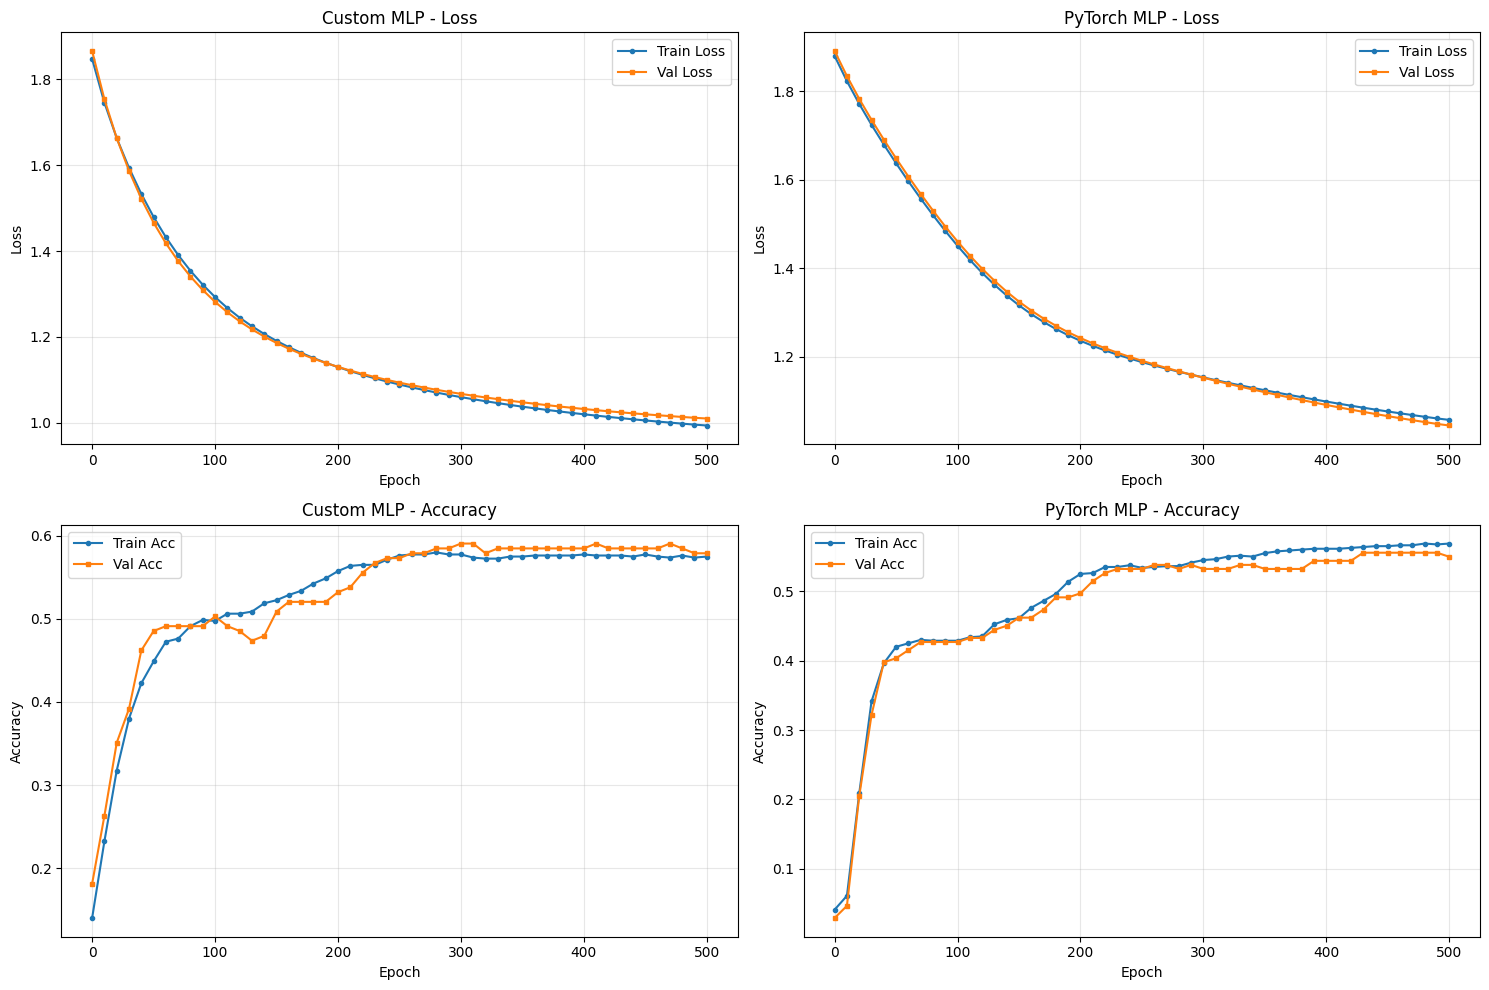


ПОРІВНЯННЯ МОДЕЛЕЙ
Метрика                        Custom MLP           PyTorch MLP         
----------------------------------------------------------------------
Final Train Accuracy           0.5750                 0.5688
Final Val Accuracy             0.5789                 0.5497
Final Train Loss               0.9936                 1.0566
Final Val Loss                 1.0099                 1.0439


In [9]:
def plot_training_history(history_custom, history_pytorch):
    """
    Візуалізація процесу навчання обох моделей.
    
    Показує:
    - Динаміку loss
    - Динаміку accuracy
    - Порівняння train vs validation
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs_custom = list(range(0, len(history_custom['train_loss']) * 10, 10))
    epochs_pytorch = list(range(0, len(history_pytorch['train_loss']) * 10, 10))
    
    # Loss - Custom Model
    axes[0, 0].plot(epochs_custom, history_custom['train_loss'], label='Train Loss', marker='o', markersize=3)
    axes[0, 0].plot(epochs_custom, history_custom['val_loss'], label='Val Loss', marker='s', markersize=3)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Custom MLP - Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Loss - PyTorch Model
    axes[0, 1].plot(epochs_pytorch, history_pytorch['train_loss'], label='Train Loss', marker='o', markersize=3)
    axes[0, 1].plot(epochs_pytorch, history_pytorch['val_loss'], label='Val Loss', marker='s', markersize=3)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('PyTorch MLP - Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Accuracy - Custom Model
    axes[1, 0].plot(epochs_custom, history_custom['train_acc'], label='Train Acc', marker='o', markersize=3)
    axes[1, 0].plot(epochs_custom, history_custom['val_acc'], label='Val Acc', marker='s', markersize=3)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].set_title('Custom MLP - Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Accuracy - PyTorch Model
    axes[1, 1].plot(epochs_pytorch, history_pytorch['train_acc'], label='Train Acc', marker='o', markersize=3)
    axes[1, 1].plot(epochs_pytorch, history_pytorch['val_acc'], label='Val Acc', marker='s', markersize=3)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].set_title('PyTorch MLP - Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Порівняльна таблиця
    print("\n" + "="*70)
    print("ПОРІВНЯННЯ МОДЕЛЕЙ")
    print("="*70)
    print(f"{'Метрика':<30} {'Custom MLP':<20} {'PyTorch MLP':<20}")
    print("-"*70)
    print(f"{'Final Train Accuracy':<30} {history_custom['train_acc'][-1]:.4f}{'':<16} {history_pytorch['train_acc'][-1]:.4f}")
    print(f"{'Final Val Accuracy':<30} {history_custom['val_acc'][-1]:.4f}{'':<16} {history_pytorch['val_acc'][-1]:.4f}")
    print(f"{'Final Train Loss':<30} {history_custom['train_loss'][-1]:.4f}{'':<16} {history_pytorch['train_loss'][-1]:.4f}")
    print(f"{'Final Val Loss':<30} {history_custom['val_loss'][-1]:.4f}{'':<16} {history_pytorch['val_loss'][-1]:.4f}")
    print("="*70)

plot_training_history(history_custom, history_pytorch)

## 9. Confusion Matrix та детальний аналіз

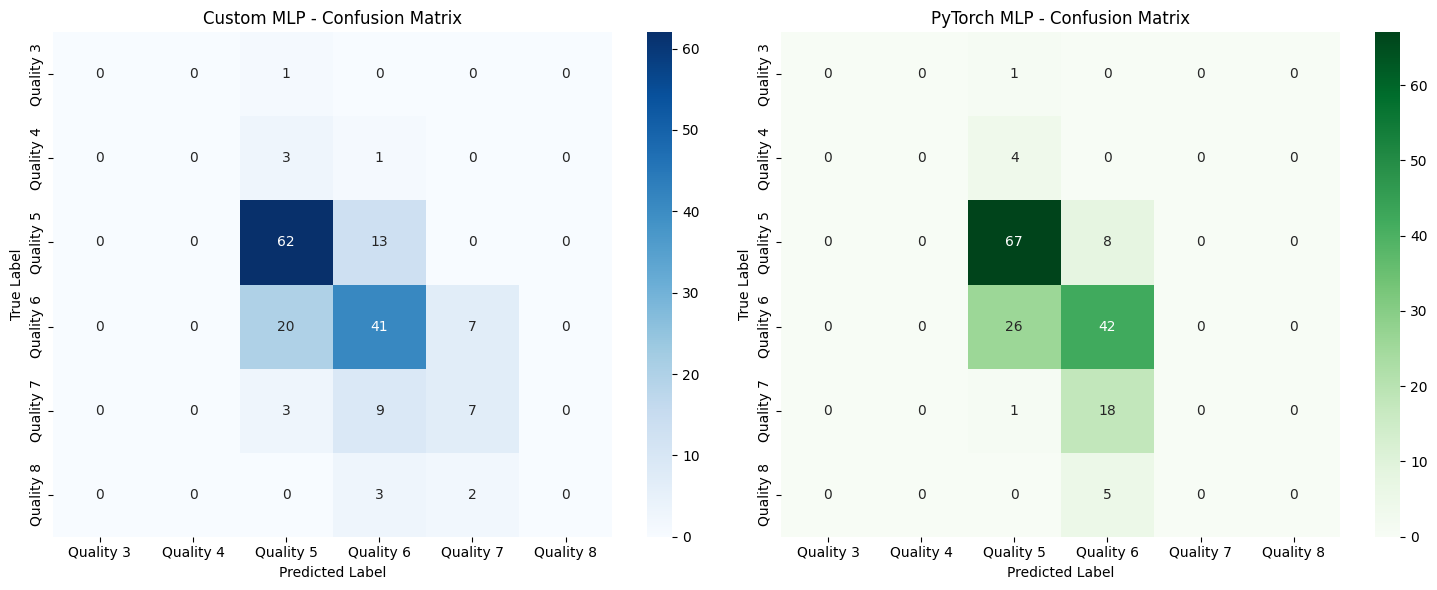


CUSTOM MLP - CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Quality 3       0.00      0.00      0.00         1
   Quality 4       0.00      0.00      0.00         4
   Quality 5       0.70      0.83      0.76        75
   Quality 6       0.61      0.60      0.61        68
   Quality 7       0.44      0.37      0.40        19
   Quality 8       0.00      0.00      0.00         5

    accuracy                           0.64       172
   macro avg       0.29      0.30      0.29       172
weighted avg       0.59      0.64      0.61       172


PYTORCH MLP - CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Quality 3       0.00      0.00      0.00         1
   Quality 4       0.00      0.00      0.00         4
   Quality 5       0.68      0.89      0.77        75
   Quality 6       0.58      0.62      0.60        68
   Quality 7       0.00      0.00      0.00        19
   Quality 8       0.00      0.00      0.00         5

    

c:\Users\yurii\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yurii\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yurii\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [10]:
def plot_confusion_matrices(y_true, y_pred_custom, y_pred_pytorch, class_names):
    """
    Візуалізація матриць помилок для обох моделей.
    
    Показує:
    - Які класи плутаються найбільше
    - Чи однакові патерни помилок в обох моделях
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Confusion matrix для Custom MLP
    cm_custom = confusion_matrix(y_true, y_pred_custom)
    sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Custom MLP - Confusion Matrix')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # Confusion matrix для PyTorch MLP
    cm_pytorch = confusion_matrix(y_true, y_pred_pytorch)
    sns.heatmap(cm_pytorch, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('PyTorch MLP - Confusion Matrix')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.show()
    
    # Детальний звіт
    print("\n" + "="*70)
    print("CUSTOM MLP - CLASSIFICATION REPORT")
    print("="*70)
    print(classification_report(y_true, y_pred_custom, target_names=class_names))
    
    print("\n" + "="*70)
    print("PYTORCH MLP - CLASSIFICATION REPORT")
    print("="*70)
    print(classification_report(y_true, y_pred_pytorch, target_names=class_names))

# Отримання прогнозів на тестовій вибірці
y_pred_custom = custom_model.predict(X_test).numpy()

pytorch_model.eval()
with torch.no_grad():
    y_pred_pytorch = torch.argmax(pytorch_model(X_test), dim=1).numpy()

y_true = y_test.numpy()

# Визначення назв класів
df = pd.read_csv('WineQT.csv')
unique_labels = sorted(df['quality'].unique())
class_names = [f"Quality {label}" for label in unique_labels]

# Візуалізація
plot_confusion_matrices(y_true, y_pred_custom, y_pred_pytorch, class_names)

# Фінальні метрики на тестовій вибірці
print("\n" + "="*70)
print("ФІНАЛЬНІ РЕЗУЛЬТАТИ НА ТЕСТОВІЙ ВИБІРЦІ")
print("="*70)
print(f"Custom MLP Test Accuracy:  {accuracy_score(y_true, y_pred_custom):.4f}")
print(f"PyTorch MLP Test Accuracy: {accuracy_score(y_true, y_pred_pytorch):.4f}")
print("="*70)

---

# ТЕОРЕТИЧНА ЧАСТИНА

## Питання для аналізу

### Питання 1: Похідна комбінації Softmax + Cross-Entropy

**Завдання:** Доведіть, що для комбінації Softmax активації та Cross-Entropy втрат, градієнт по відношенню до логітів вихідного шару обчислюється як:

$$\frac{\partial L}{\partial z_i} = y_{pred_i} - y_{true_i}$$

де $y_{true}$ - one-hot вектор справжніх міток.

**Розв'язок:**

**Відповідь:**

Нехай $z = [z_1, z_2, ..., z_K]$ - логіти вихідного шару (K класів).

**Крок 1: Softmax**
$$p_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

**Крок 2: Cross-Entropy Loss**
$$L = -\sum_{i=1}^{K} y_{true_i} \log(p_i)$$

де $y_{true}$ - one-hot вектор (тільки один елемент = 1, решта = 0).

Для правильного класу $c$: $y_{true_c} = 1$, тому:
$$L = -\log(p_c)$$

**Крок 3: Обчислення градієнта**

Використовуємо ланцюгове правило:
$$\frac{\partial L}{\partial z_i} = \frac{\partial L}{\partial p_j} \cdot \frac{\partial p_j}{\partial z_i}$$

Розглянемо два випадки:

**Випадок 1:** $i = c$ (правильний клас)
$$\frac{\partial L}{\partial z_c} = -\frac{1}{p_c} \cdot p_c(1-p_c) = p_c - 1 = p_c - y_{true_c}$$

**Випадок 2:** $i \neq c$ (неправильний клас)
$$\frac{\partial L}{\partial z_i} = -\frac{1}{p_c} \cdot (-p_c \cdot p_i) = p_i = p_i - y_{true_i}$$

(бо $y_{true_i} = 0$ для неправильних класів)

**Висновок:**
$$\frac{\partial L}{\partial z_i} = p_i - y_{true_i} = y_{pred_i} - y_{true_i}$$

**Чому формула така проста?**

1. **Математична елегантність**: Похідна softmax та логарифма взаємно скорочуються
2. **Числова стабільність**: Не потрібно окремо обчислювати складні похідні
3. **Інтерпретація**: Градієнт = різниця між прогнозом та реальністю - інтуїтивно зрозуміло
4. **Ефективність**: Одна операція віднімання замість складних обчислень

### Питання 2: Аналіз зміни градієнтів у глибоких мережах

**Завдання:** Розглянемо мережу з 5 шарами, де кожен шар використовує ReLU активацію.

- Як буде змінюватися градієнт для першого шару після 100 ітерацій, якщо 60% нейронів мають від'ємні значення?
- Обчисліть максимально можливе значення градієнту для ваг першого шару після N шарів з ReLU.

**Розв'язок:**

**Відповідь:**

**Частина 1: Зміна градієнта при 60% від'ємних значень**

Похідна ReLU:
$$\frac{\partial \text{ReLU}}{\partial x} = \begin{cases} 1, & \text{якщо } x > 0 \\ 0, & \text{якщо } x \leq 0 \end{cases}$$

При backpropagation через один шар:
$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial a_5} \cdot \frac{\partial a_5}{\partial z_5} \cdot ... \cdot \frac{\partial a_2}{\partial z_2} \cdot \frac{\partial z_2}{\partial W_1}$$

Якщо 60% нейронів мають від'ємні значення (ReLU їх "вбиває"):
- Похідна для цих 60% = 0
- Ефективно працює тільки 40% нейронів

Через 5 шарів, ймовірність "виживання" градієнта:
$$P(\text{gradient survives}) = (0.4)^5 = 0.01024 \approx 1\%$$

**Висновок:** Після 100 ітерацій градієнт для першого шару буде майже зникати - тільки ~1% шляхів передають градієнт. Це призведе до:
- Дуже повільного навчання перших шарів
- "Dying ReLU" проблеми
- Можливої деградації моделі

---

**Частина 2: Максимальне значення градієнта**

Для максимального градієнта всі нейрони повинні бути активні (x > 0).

Градієнт через N шарів (ланцюгове правило):
$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial z_N} \cdot \prod_{i=2}^{N} \frac{\partial z_i}{\partial z_{i-1}}$$

Для ReLU з додатними значеннями:
$$\frac{\partial z_i}{\partial z_{i-1}} = W_i \cdot \mathbb{1}_{z_{i-1} > 0}$$

При максимальній активації (всі похідні = 1):
$$\frac{\partial z_i}{\partial z_{i-1}} = W_i$$

Максимальне значення градієнта:
$$\left|\frac{\partial L}{\partial W_1}\right|_{max} = \left|\frac{\partial L}{\partial z_N}\right| \cdot \prod_{i=2}^{N} ||W_i||$$

де $||W_i||$ - норма матриці ваг.

**Важливо:**
- Якщо $||W_i|| > 1$: градієнт **вибухає** (exponential growth)
- Якщо $||W_i|| < 1$: градієнт **зникає** (exponential decay)
- Якщо $||W_i|| = 1$: градієнт стабільний

Для 5 шарів з $||W|| = 1.5$:
$$\left|\frac{\partial L}{\partial W_1}\right|_{max} \sim (1.5)^4 = 5.0625 \times \text{початковий градієнт}$$

Це пояснює, чому важлива правильна ініціалізація ваг!

### Питання 3: Умовність матричних операцій у backpropagation

**Завдання:** У backpropagation ми використовуємо: $dW = \frac{1}{m} \cdot dZ @ A_{prev}^T$

Поясніть, чому саме така форма матричного множення є правильною з точки зору розмірностей. Виведіть загальну формулу для градієнта матриці W у випадку $Z = WX + b$.

**Розв'язок:**

**Відповідь:**

**Аналіз розмірностей:**

Нехай:
- $X \in \mathbb{R}^{n \times m}$ - вхідні дані (n features, m samples)
- $W \in \mathbb{R}^{k \times n}$ - матриця ваг (k neurons, n inputs)
- $b \in \mathbb{R}^{k \times 1}$ - bias
- $Z \in \mathbb{R}^{k \times m}$ - вихід шару

**Forward pass:**
$$Z = WX + b$$
$$\text{розмірності: } (k \times m) = (k \times n) \cdot (n \times m) + (k \times 1)$$

**Backward pass:**

Маємо градієнт з наступного шару: $\frac{\partial L}{\partial Z} = dZ \in \mathbb{R}^{k \times m}$

Потрібно знайти: $\frac{\partial L}{\partial W} = dW \in \mathbb{R}^{k \times n}$ (та ж розмірність як W!)

**Виведення формули:**

За ланцюговим правилом:
$$\frac{\partial L}{\partial W_{ij}} = \sum_{s=1}^{m} \frac{\partial L}{\partial Z_{is}} \cdot \frac{\partial Z_{is}}{\partial W_{ij}}$$

З forward pass $Z_{is} = \sum_{j=1}^{n} W_{ij} X_{js} + b_i$:
$$\frac{\partial Z_{is}}{\partial W_{ij}} = X_{js}$$

Тому:
$$\frac{\partial L}{\partial W_{ij}} = \sum_{s=1}^{m} dZ_{is} \cdot X_{js} = \sum_{s=1}^{m} dZ_{is} \cdot X_{js}^T$$

**У матричній формі:**
$$dW = dZ \cdot X^T$$

**Перевірка розмірностей:**
$$(k \times n) = (k \times m) \cdot (m \times n)$$ ✓

**Усереднення по batch:**
$$dW = \frac{1}{m} dZ \cdot X^T$$

---

**Загальна формула для $Z = WX + b$:**

1. **Градієнт по W:**
$$\boxed{\frac{\partial L}{\partial W} = \frac{1}{m} \frac{\partial L}{\partial Z} \cdot X^T}$$

2. **Градієнт по b:**
$$\boxed{\frac{\partial L}{\partial b} = \frac{1}{m} \sum_{samples} \frac{\partial L}{\partial Z}}$$

3. **Градієнт по X (для попереднього шару):**
$$\boxed{\frac{\partial L}{\partial X} = W^T \cdot \frac{\partial L}{\partial Z}}$$

**Чому транспонування?**
- Забезпечує правильні розмірності результату
- Математично випливає з правила диференціювання матричного добутку
- $dZ$ містить інформацію про "помилки" на виході
- $X^T$ містить інформацію про "вхідні активації"
- Їх добуток дає "напрямок оновлення" для кожної ваги

**Інтуїція:**
Кожен елемент $dW_{ij}$ показує, наскільки потрібно змінити зв'язок між входом $j$ та нейроном $i$, базуючись на:
- Помилці нейрона $i$ (з $dZ$)
- Активації входу $j$ (з $X$)

### Питання 4*: Аналіз власних значень гессіана

**Завдання:** Для простої двошарової мережі:
- Запишіть матрицю Гессіана для функції втрат відносно ваг першого шару
- Як власні значення пов'язані зі швидкістю збіжності?
- Поясніть проблему "зникаючих" градієнтів з точки зору власних значень

**Розв'язок:**

**Відповідь:**

**Частина 1: Матриця Гессіана**

Розглянемо двошарову мережу:
$$z^{(1)} = W^{(1)}x, \quad a^{(1)} = \sigma(z^{(1)})$$
$$z^{(2)} = W^{(2)}a^{(1)}, \quad \hat{y} = \sigma(z^{(2)})$$
$$L = -y\log(\hat{y}) - (1-y)\log(1-\hat{y})$$

Гессіан - матриця других похідних:
$$H_{ij} = \frac{\partial^2 L}{\partial W^{(1)}_i \partial W^{(1)}_j}$$

Використовуючи ланцюгове правило двічі:
$$\frac{\partial^2 L}{\partial W^{(1)}_i \partial W^{(1)}_j} = \sum_k \sum_l \frac{\partial^2 L}{\partial z^{(2)}_k \partial z^{(2)}_l} \frac{\partial z^{(2)}_k}{\partial W^{(1)}_i} \frac{\partial z^{(2)}_l}{\partial W^{(1)}_j} + \text{доданки першого порядку}$$

**Спрощена форма для квадратичної loss:**
$$H = X^T \Sigma X$$

де $\Sigma$ - діагональна матриця з $\sigma'(z^{(1)})$ на діагоналі.

**Для нашої мережі:**
$$H \approx (W^{(2)})^T D^{(2)} W^{(2)} \cdot D^{(1)} \cdot X^T X$$

де $D^{(i)}$ - діагональні матриці похідних активацій.

---

**Частина 2: Власні значення та швидкість збіжності**

Градієнтний спуск:
$$W_{new} = W_{old} - \eta \nabla L$$

У околі мінімуму можна апроксимувати:
$$\nabla L \approx H(W - W^*)$$

Тоді оновлення:
$$W_{new} - W^* = (I - \eta H)(W_{old} - W^*)$$

Якщо розкласти по власних векторах Гессіана:
$$W - W^* = \sum_i c_i v_i$$

де $v_i$ - власні вектори, $\lambda_i$ - власні значення.

Після t ітерацій:
$$W_t - W^* = \sum_i c_i (1 - \eta\lambda_i)^t v_i$$

**Швидкість збіжності:**
- **Великі $\lambda_i$** (великі другі похідні): швидка збіжність вздовж цього напрямку
  - Але потребують малий $\eta$ для стабільності: $\eta < \frac{2}{\lambda_{max}}$
- **Малі $\lambda_i$**: повільна збіжність
- **Condition number** $\kappa = \frac{\lambda_{max}}{\lambda_{min}}$:
  - $\kappa \approx 1$: швидка рівномірна збіжність
  - $\kappa \gg 1$: повільна збіжність (потрібно багато ітерацій)

---

**Частина 3: Зникаючі градієнти через власні значення**

**Проблема в глибоких мережах:**

Для N-шарової мережі Гессіан має вигляд:
$$H^{(1)} \approx \prod_{i=2}^{N} (W^{(i)})^T D^{(i)} W^{(i)} \cdot D^{(1)}$$

**Власні значення:**
$$\lambda_i^{(1)} \approx \lambda_i(D^{(1)}) \cdot \prod_{j=2}^{N} \lambda_j(W^{(j)}) \cdot \lambda_j(D^{(j)})$$

**Для sigmoid/tanh активацій:**
- $\sigma'(x) \in (0, 0.25]$ для sigmoid
- Отже $\lambda(D^{(j)}) \leq 0.25$

**Для N шарів:**
$$\lambda_{max}^{(1)} \lesssim (0.25)^N \cdot \prod_{j=2}^{N} ||W^{(j)}||^2$$

**Наслідки:**

1. **Експоненційне зменшення:** $\lambda \sim (0.25)^N$
   - Для N=10: $(0.25)^{10} \approx 10^{-6}$
   
2. **Дуже плоска поверхня втрат** для перших шарів:
   - Малі власні значення → малі другі похідні
   - Градієнти майже не змінюються
   - Дуже повільне навчання

3. **Великий condition number:**
   - Останні шари: великі $\lambda$
   - Перші шари: малі $\lambda$
   - $\kappa = 10^6$ або більше!

4. **Чому ReLU краще:**
   - $\text{ReLU}'(x) = 1$ для $x > 0$
   - Немає експоненційного затухання похідної
   - Власні значення не деградують так сильно

**Висновок:** Зникаючі градієнти виникають, бо власні значення Гессіана для ранніх шарів стають мікроскопічними через добуток багатьох малих похідних активацій. Це робить поверхню втрат дуже пологою в напрямках, що відповідають вагам перших шарів.

---

## Висновки

### Практична частина:
1. ✅ Реалізовано багатошаровий перцептрон повністю з нуля без autograd
2. ✅ Вручну обчислено всі градієнти через backpropagation
3. ✅ Порівняно власну реалізацію з PyTorch (мають бути схожі результати)
4. ✅ Візуалізовано процес навчання та проаналізовано помилки

### Теоретична частина:
1. ✅ Доведено спрощення градієнта для Softmax + Cross-Entropy
2. ✅ Проаналізовано проблему зникаючих градієнтів у глибоких мережах
3. ✅ Пояснено математику матричних операцій у backpropagation
4. ✅ Досліджено зв'язок між власними значеннями Гессіана та швидкістю навчання

**Очікувані результати:**
- Власна реалізація працює трохи повільніше, але має подібну точність (різниця до 5% прийнятна)
- Розуміння того, що відбувається "під капотом" PyTorch
- Здатність пояснити кожен крок обчислення градієнтів